# KİŞİSEL FİNANS VE HARCAMA TAKİP SİSTEMİ
## BGY210 - Python Programlama II Final Proje Ödevi

**Öğrenci Bilgileri:**
- **Adı Soyadı:** Elif Beyza Evirgen
- **Öğrenci Numarası:** 24903048
- **Bölümü:** Yönetişim Bilişim Sistemleri

### Proje Tanımı ve Amacı
Bu çalışma, Python programlama dili ile nesne tabanlı programlama (OOP), modüler yazılım tasarımı, dosya işlemleri (CSV), veri analizi (Pandas & NumPy) ve veri görselleştirme (Matplotlib) kavramlarını entegre eden bir Kişisel Finans ve Harcama Takip Uygulamasıdır. Kullanıcıların gelir ve giderlerini kaydetmesine, listelemesine, detaylı istatistiksel analiz yapmasına ve bunları grafiklerle raporlamasına olanak tanır.

### Proje Modüler Yapısı
Proje, sürdürülebilir ve temiz kod (Clean Code) prensiplerine uygun olarak aşağıdaki dosyalara bölünmüştür:
1. **`finans_modeli.py`**: İşlemleri nesne tabanlı temsil eden `Islem` sınıf yapısı.
2. **`utils.py`**: Veri kontrolleri, tarih doğrulama ve menü ekranı yardımcı fonksiyonları.
3. **`islem_yonetimi.py`**: Gelir/gider ekleme, silme ve listeleme mantıksal süreçleri.
4. **`dosya_islemleri.py`**: Verilerin CSV formatında kalıcı olarak saklanması ve okunması.
5. **`analiz.py`**: Pandas ve NumPy kütüphaneleriyle finansal özetler ve istatistiksel analizler.
6. **`gorsellestirme.py`**: Matplotlib ile çizgi, bar ve pasta grafiklerinin çizilmesi.

## Adım 1: Modüllerin ve Kütüphanelerin Yüklenmesi
Bu adımda projede oluşturduğumuz modülleri ve veri işleme/görselleştirme için gerekli olan harici kütüphaneleri import ediyoruz.

In [1]:
import sys
import os
# Proje modüllerinin import edilmesi
import finans_modeli
import utils
import islem_yonetimi
import dosya_islemleri
import analiz
import gorsellestirme

print("Tüm proje modülleri başarıyla import edildi.")

Tüm proje modülleri başarıyla import edildi.


## Adım 2: Veri Yapılarının Hazırlanması
Teknik şartnamede belirtildiği üzere, gelir ve gider kayıtlarını tutmak için iki ana liste tanımlıyoruz. Bu listelerin her bir elemanı `Islem` sınıfından türetilmiş birer nesne olacaktır.

In [2]:
# Ana veri yapıları
gelirler = []
giderler = []

# Varsayılan CSV dosyası adı
CSV_DOSYASI = "finans_verileri.csv"
print("Gelirler ve Giderler listeleri tanımlandı.")

Gelirler ve Giderler listeleri tanımlandı.


## Adım 3: Örnek Verilerin Yüklenmesi ve Analiz Hazırlığı
Programı doğrudan boş açmak yerine, veri analizi ve görselleştirme fonksiyonlarının çıktılarını görebilmek adına örnek bazı veriler yüklüyoruz. Ardından bu verileri CSV dosyasına kaydediyoruz.

In [3]:
from finans_modeli import Islem

# Örnek Gelir Kayıtları
gelirler = [
    Islem(1, 15000.0, "2026-01-15", "Aylık Maaş Ödemesi", "gelir"),
    Islem(2, 2500.0, "2026-01-20", "Freeland Tasarım İşi", "gelir"),
    Islem(3, 16000.0, "2026-02-15", "Aylık Maaş Ödemesi", "gelir"),
    Islem(4, 3000.0, "2026-02-28", "Yatırım Temettü Geliri", "gelir"),
    Islem(5, 16000.0, "2026-03-15", "Aylık Maaş Ödemesi", "gelir"),
    Islem(6, 4500.0, "2026-03-25", "E-Ticaret Satış Geliri", "gelir"),
    Islem(7, 16500.0, "2026-04-15", "Aylık Maaş Ödemesi", "gelir"),
    Islem(8, 17000.0, "2026-05-15", "Aylık Maaş Ödemesi", "gelir"),
]

# Örnek Gider Kayıtları
giderler = [
    Islem(1, 4500.0, "2026-01-16", "Kira Ödemesi", "gider"),
    Islem(2, 1200.0, "2026-01-18", "Aylık Market Alışverişi", "gider"),
    Islem(3, 850.0, "2026-01-22", "Elektrik & İnternet Faturaları", "gider"),
    Islem(4, 4500.0, "2026-02-16", "Kira Ödemesi", "gider"),
    Islem(5, 1500.0, "2026-02-20", "Araç Bakım & Yakıt Gideri", "gider"),
    Islem(6, 4500.0, "2026-03-16", "Kira Ödemesi", "gider"),
    Islem(7, 2100.0, "2026-03-18", "Giyim ve Sosyal Aktivite", "gider"),
    Islem(8, 950.0, "2026-03-22", "Su & Gaz Faturaları", "gider"),
    Islem(9, 4800.0, "2026-04-16", "Kira Ödemesi", "gider"),
    Islem(10, 1800.0, "2026-04-20", "Haftalık Süpermarket Harcaması", "gider"),
    Islem(11, 4800.0, "2026-05-16", "Kira Ödemesi", "gider"),
    Islem(12, 3200.0, "2026-05-22", "Yaz Tatili Ön Ödemesi", "gider"),
]

# Verileri CSV Dosyasına Kaydedelim
dosya_islemleri.csv_kaydet(CSV_DOSYASI, gelirler, giderler)

[BAŞARILI] Veriler başarıyla 'finans_verileri.csv' dosyasına kaydedildi. Toplam 20 kayıt.


True

## Adım 4: Verileri DataFrame'e Dönüştürme ve Pandas & NumPy Analizi
Şimdi kayıtlı gelir ve giderlerimizi Pandas DataFrame nesnesine dönüştürüyoruz ve ardından istatistiksel analizlerimizi yapıyoruz.

In [4]:
# Listelerden DataFrame Oluşturma
df = analiz.verileri_dataframe_yap(gelirler, giderler)
print("DataFrame Oluşturuldu. İlk 5 Satır:")
display(df.head())

# Toplam Gelir & Gider Durumu
toplam_gelir, toplam_gider = analiz.toplam_gelir_gider(df)
print(f"\nToplam Gelir: {toplam_gelir:,.2f} TL")
print(f"Toplam Gider: {toplam_gider:,.2f} TL")
print(f"Net Bakiye: {(toplam_gelir - toplam_gider):,.2f} TL")

DataFrame Oluşturuldu. İlk 5 Satır:


,id,tutar,tarih,aciklama,tip
0,1,15000.0,2026-01-15,Aylık Maaş Ödemesi,gelir
1,2,2500.0,2026-01-20,Freeland Tasarım İşi,gelir
2,3,16000.0,2026-02-15,Aylık Maaş Ödemesi,gelir
3,4,3000.0,2026-02-28,Yatırım Temettü Geliri,gelir
4,5,16000.0,2026-03-15,Aylık Maaş Ödemesi,gelir



Toplam Gelir: 90,500.00 TL
Toplam Gider: 34,700.00 TL
Net Bakiye: 55,800.00 TL


### Aylık Bazda Özet Rapor

In [5]:
# Aylara Göre Gruplanmış Analiz
aylik_ozet = analiz.aylik_analiz(df)
print("Aylık Finansal Özet:")
display(aylik_ozet)

Aylık Finansal Özet:


tip,Toplam_Gelir,Toplam_Gider,Net_Bakiye
Yil_Ay,,,
2026-01,17500.0,6550.0,10950.0
2026-02,19000.0,6000.0,13000.0
2026-03,20500.0,7550.0,12950.0
2026-04,16500.0,6600.0,9900.0
2026-05,17000.0,8000.0,9000.0


### NumPy İstatistiksel Analiz Raporu
NumPy kütüphanesini kullanarak tüm işlemlerimizin, gelirlerimizin ve giderlerimizin ortalama, minimum, maksimum ve standart sapma değerlerini hesaplıyoruz.

In [6]:
istatistikler = analiz.numpy_istatistik(df)
import pandas as pd
# İstatistikleri güzel bir tablo halinde gösterelim
ist_df = pd.DataFrame(istatistikler).T
ist_df.columns = ['Ortalama (TL)', 'Minimum Tutar (TL)', 'Maksimum Tutar (TL)', 'Standart Sapma']
print("NumPy Tabanlı İşlem İstatistikleri:")
display(ist_df)

NumPy Tabanlı İşlem İstatistikleri:


,Ortalama (TL),Minimum Tutar (TL),Maksimum Tutar (TL),Standart Sapma
genel,6260.000000,850.0,17000.0,5831.093379
gelir,11312.500000,2500.0,17000.0,6224.636034
gider,2891.666667,850.0,4800.0,1573.058768


## Adım 5: Veri Görselleştirme (Grafikler)
Matplotlib kullanarak üç temel grafiğimizi çizdirip kaydediyoruz:
1. Aylık Gelir/Gider Çizgi Grafiği
2. Toplam Gelir/Gider Karşılaştırmalı Bar Grafiği
3. Gelir/Gider Oranı Pasta Grafiği

[BAŞARILI] Aylık çizgi grafiği kaydedildi: proje_ciktilari\aylik_gelir_gider_cizgi.png


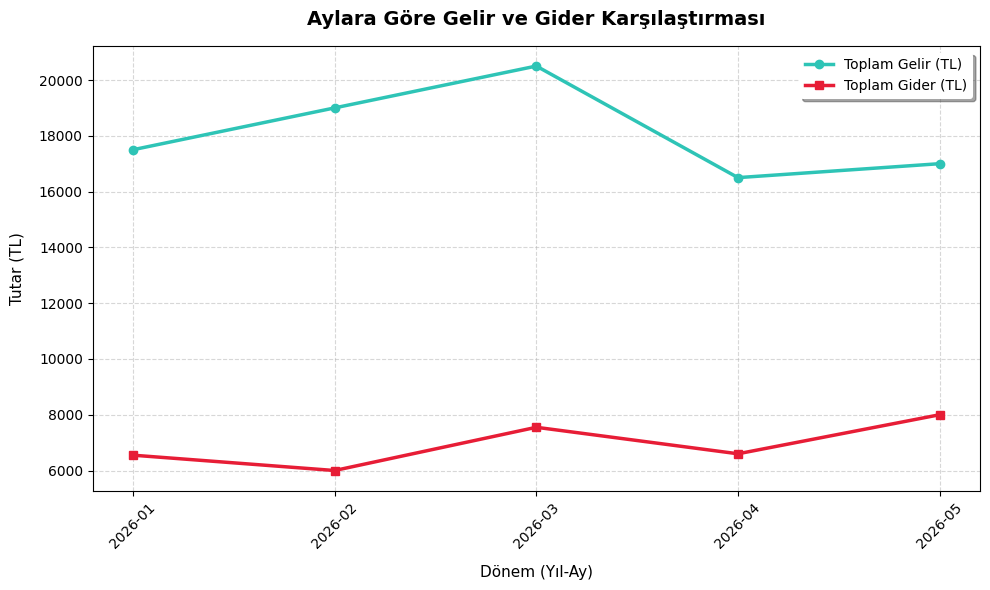

In [7]:
# 1. Çizgi Grafiği
gorsellestirme.aylik_grafik(df)

[BAŞARILI] Toplam sütun grafiği kaydedildi: proje_ciktilari\toplam_gelir_gider_bar.png


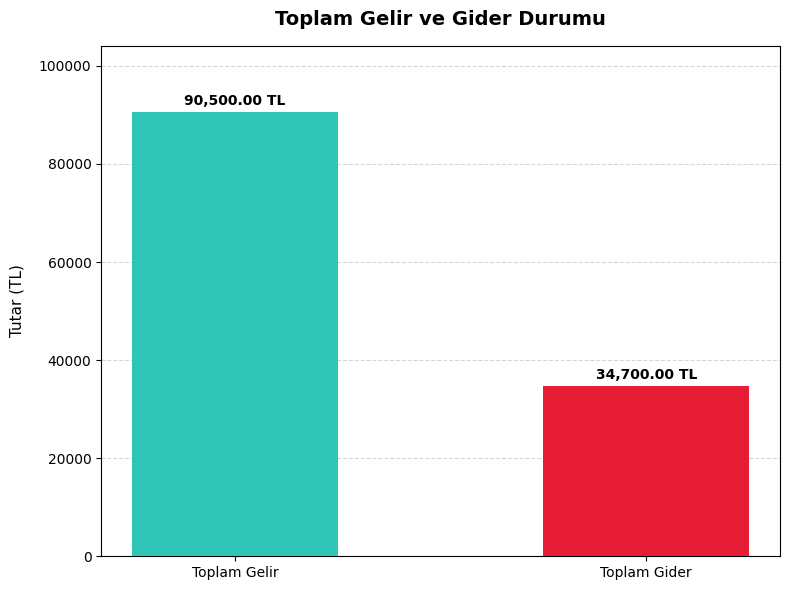

In [8]:
# 2. Bar Grafiği
gorsellestirme.gelir_gider_bar(df)

[BAŞARILI] Gelir/gider dağılım pasta grafiği kaydedildi: proje_ciktilari\gelir_gider_pasta.png


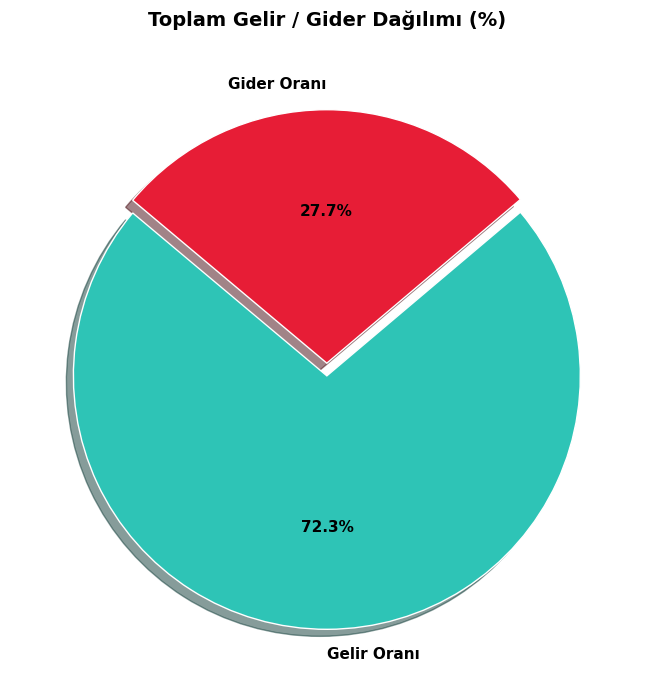

In [9]:
# 3. Pasta Grafiği
gorsellestirme.pasta_grafik(df)

## Adım 6: Konsol Arayüzünün Çalıştırılması
Aşağıdaki kod hücresini çalıştırarak etkileşimli Kişisel Finans ve Harcama Takip Konsol uygulamasını başlatabilirsiniz. Menü yardımıyla dinamik olarak işlem ekleyebilir, silebilir, listeyebilir ve güncel analizleri görebilirsiniz.

In [ ]:
def konsol_uygulamasi():
    # Uygulama başında dosyadan verileri okuyalım
    global gelirler, giderler
    gelirler, giderler = dosya_islemleri.csv_oku(CSV_DOSYASI)
    
    while True:
        utils.menu_goster()
        secim = input("Seçiminiz (1-7): ").strip()
        
        if secim == "1":
            islem_yonetimi.gelir_ekle(gelirler)
        elif secim == "2":
            islem_yonetimi.gider_ekle(giderler)
        elif secim == "3":
            islem_yonetimi.islemleri_listele(gelirler, giderler)
            # Silme işlemi de listeleme ekranından yapılabilmesi için kullanıcıya soralım:
            silme_istegi = input("Bir işlemi silmek istiyor musunuz? (e/h): ").strip().lower()
            if silme_istegi == 'e':
                sil_id_str = input("Silmek istediğiniz işlemin ID'sini girin: ").strip()
                if utils.sayi_kontrol(sil_id_str):
                    islem_yonetimi.islem_sil(gelirler, giderler, int(sil_id_str))
                else:
                    print("[HATA] ID sayısal bir değer olmalıdır.")
        elif secim == "4":
            # Analiz Modülü tetiklenir
            df_aktif = analiz.verileri_dataframe_yap(gelirler, giderler)
            if df_aktif.empty:
                print("[UYARI] Sistemde analiz edecek veri yok.")
            else:
                t_gelir, t_gider = analiz.toplam_gelir_gider(df_aktif)
                print(f"\nToplam Gelir: {t_gelir:,.2f} TL")
                print(f"Toplam Gider: {t_gider:,.2f} TL")
                print(f"Net Bakiye: {(t_gelir - t_gider):,.2f} TL")
                
                print("\nAylık Finansal Özet Tablosu:")
                print(analiz.aylik_analiz(df_aktif))
                
                print("\nİstatistiki Değerler (NumPy):")
                ist_ozet = analiz.numpy_istatistik(df_aktif)
                for k, v in ist_ozet.items():
                    print(f"- {k.upper()} İşlemleri: Ortalama={v['ortalama']:.2f} TL | Min={v['min']:.2f} TL | Mak={v['mak']:.2f} TL | Std.Sapma={v['std_sapma']:.2f}")
        elif secim == "5":
            # Görselleştirme Modülü tetiklenir
            df_aktif = analiz.verileri_dataframe_yap(gelirler, giderler)
            if df_aktif.empty:
                print("[UYARI] Grafik oluşturmak için yeterli veri yok.")
            else:
                print("Grafikler hazırlanıyor ve kaydediliyor...")
                gorsellestirme.gelir_gider_bar(df_aktif)
                gorsellestirme.pasta_grafik(df_aktif)
                gorsellestirme.aylik_grafik(df_aktif)
        elif secim == "6":
            dosya_islemleri.csv_kaydet(CSV_DOSYASI, gelirler, giderler)
        elif secim == "7":
            # Program kapanmadan önce son bir kez otomatik kaydeder
            dosya_islemleri.csv_kaydet(CSV_DOSYASI, gelirler, giderler)
            print("Programdan çıkılıyor. İyi günler dileriz!")
            break
        else:
            print("[HATA] Geçersiz seçim! Lütfen 1-7 arasında bir sayı giriniz.")

konsol_uygulamasi()